In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"

print("Project root:", ROOT)
print("Data folder:", DATA_DIR)

Project root: c:\Users\ghena\OneDrive\Desktop\ML Project
Data folder: c:\Users\ghena\OneDrive\Desktop\ML Project\data


In [2]:
train = pd.read_csv(DATA_DIR / "train-test.csv")
validation = pd.read_csv(DATA_DIR / "validation.csv")
december = pd.read_csv(DATA_DIR / "december-chart-inputs.csv")
template = pd.read_csv(DATA_DIR / "validation-predictions-template.csv")

print("Train:", train.shape)
print("Validation:", validation.shape)
print("December:", december.shape)
print("Template:", template.shape)

Train: (48000, 14)
Validation: (12000, 13)
December: (31, 7)
Template: (12000, 2)


In [4]:
print("TRAIN:")
display(train.head())

print("\nVALIDATION:")
display(validation.head())

print("\nTRAIN INFO:")
train.info()

TRAIN:


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28



VALIDATION:


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541



TRAIN INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [6]:
print("Train columns:", train.columns.tolist())

print("\nValidation columns:", validation.columns.tolist())


Train columns: ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

Validation columns: ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']


In [8]:
# DATA QUALITY AUDIT


print("Missing values - TRAIN")
display(
    train.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
    .assign(
        missing_pct=lambda x: (x["missing_count"] / len(train) * 100).round(2)
    )
)

print("\nMissing values - VALIDATION")
display(
    validation.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
    .assign(
        missing_pct=lambda x: (x["missing_count"] / len(validation) * 100).round(2)
    )
)

Missing values - TRAIN


,missing_count,missing_pct
market_index,374,0.78
weight,300,0.62
delivery,0,0.00
pickup_lat,0,0.00
load_id,0,0.00
pickup,0,0.00
delivery_lat,0,0.00
pickup_lon,0,0.00
distance,0,0.00
delivery_lon,0,0.00



Missing values - VALIDATION


,missing_count,missing_pct
market_index,249,2.08
weight,165,1.38
delivery,0,0.00
pickup,0,0.00
load_id,0,0.00
pickup_lon,0,0.00
pickup_lat,0,0.00
delivery_lat,0,0.00
delivery_lon,0,0.00
equipment,0,0.00


In [9]:
# DUPLICATES & UNIQUE IDS

print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in validation:", validation.duplicated().sum())

print("Duplicate train load_ids:", train["load_id"].duplicated().sum())
print("Duplicate validation load_ids:", validation["load_id"].duplicated().sum())

print("\nUnique values:")
print("Pickup locations:", train["pickup"].nunique())
print("Delivery locations:", train["delivery"].nunique())
print("Equipment types:", train["equipment"].nunique())

Duplicate rows in train: 0
Duplicate rows in validation: 0
Duplicate train load_ids: 0
Duplicate validation load_ids: 0

Unique values:
Pickup locations: 64
Delivery locations: 64
Equipment types: 3


In [10]:
# TARGET ANALYSIS

print("Posted rate summary:")
display(train["posted_rate"].describe())

print("\nTarget missing values:", train["posted_rate"].isna().sum())

print("\nTarget quantiles:")
display(
    train["posted_rate"]
    .quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])
    .to_frame("posted_rate")
)

Posted rate summary:


count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64


Target missing values: 0

Target quantiles:


,posted_rate
0.00,57.2200
0.01,327.1688
0.05,599.7385
0.25,1251.5550
0.50,2030.7600
0.75,3330.7500
0.95,4953.7665
0.99,5972.8340
1.00,25533.0000


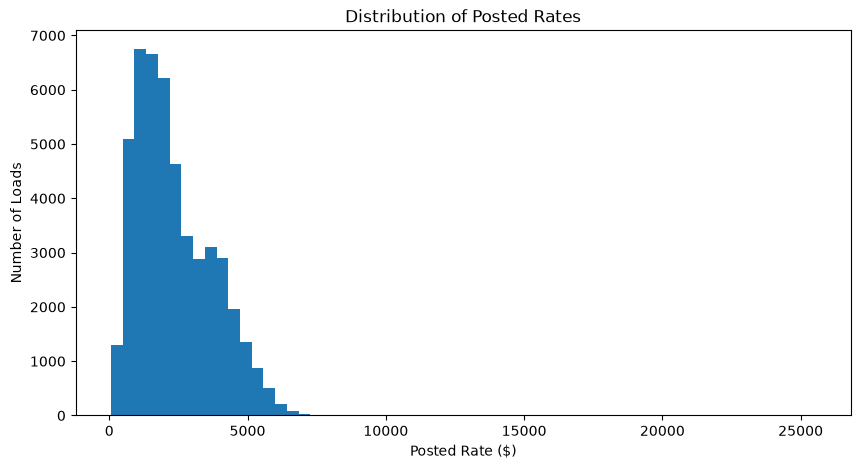

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(train["posted_rate"], bins=60)

plt.xlabel("Posted Rate ($)")
plt.ylabel("Number of Loads")
plt.title("Distribution of Posted Rates")


plt.show()

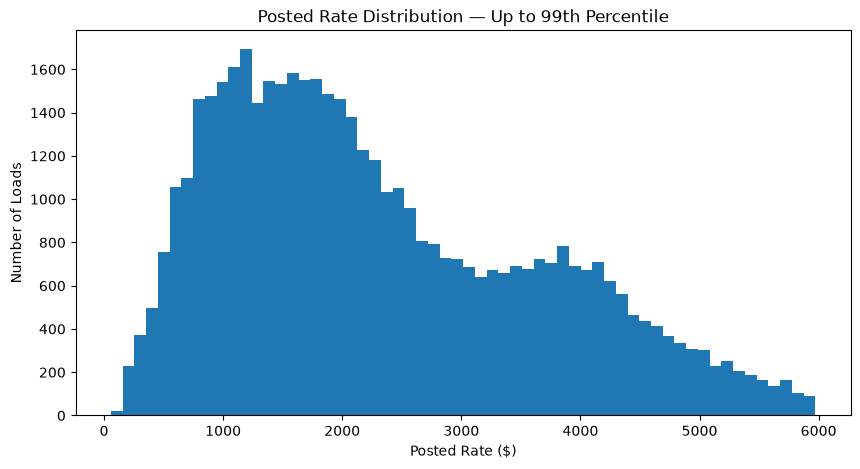

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    train.loc[train["posted_rate"] <= train["posted_rate"].quantile(0.99), "posted_rate"],
    bins=60
)

plt.xlabel("Posted Rate ($)")
plt.ylabel("Number of Loads")
plt.title("Posted Rate Distribution — Up to 99th Percentile")

plt.show()

In [13]:
# TIME ANALYSIS


train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])
december["date"] = pd.to_datetime(december["date"])

print("Train date range:")
print(train["date"].min(), "→", train["date"].max())

print("\nValidation date range:")
print(validation["date"].min(), "→", validation["date"].max())

Train date range:
2025-01-01 00:00:00 → 2025-10-31 00:00:00

Validation date range:
2025-11-01 00:00:00 → 2025-12-31 00:00:00


In [14]:
monthly_rate = (
    train
    .set_index("date")["posted_rate"]
    .resample("ME")
    .agg(["mean", "median", "count"])
)

display(monthly_rate)

,mean,median,count
date,,,
2025-01-31,2255.967048,1915.200,4918
2025-02-28,2273.804801,1994.250,4337
2025-03-31,2372.268092,2022.920,5036
2025-04-30,2372.162308,2044.240,4819
2025-05-31,2421.776342,2065.510,4913
2025-06-30,2497.030115,2120.220,4783
2025-07-31,2415.162030,2059.145,4912
2025-08-31,2338.407661,2015.730,4759
2025-09-30,2406.374013,2057.130,4670


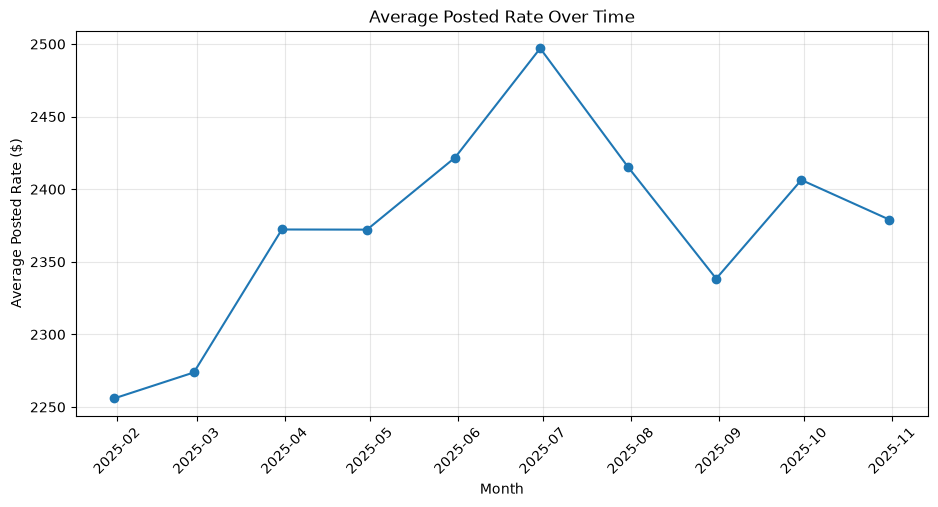

In [15]:
plt.figure(figsize=(11, 5))

plt.plot(monthly_rate.index, monthly_rate["mean"], marker="o")

plt.xlabel("Month")
plt.ylabel("Average Posted Rate ($)")
plt.title("Average Posted Rate Over Time")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

In [16]:
print("TRAIN DATE RANGE")
print("Start:", train["date"].min())
print("End:  ", train["date"].max())

print("\nVALIDATION DATE RANGE")
print("Start:", validation["date"].min())
print("End:  ", validation["date"].max())

print("\nTRAIN ROWS BY MONTH")
display(
    train.groupby(train["date"].dt.to_period("M"))
    .size()
    .to_frame("rows")
)

print("\nVALIDATION ROWS BY MONTH")
display(
    validation.groupby(validation["date"].dt.to_period("M"))
    .size()
    .to_frame("rows")
)

TRAIN DATE RANGE
Start: 2025-01-01 00:00:00
End:   2025-10-31 00:00:00

VALIDATION DATE RANGE
Start: 2025-11-01 00:00:00
End:   2025-12-31 00:00:00

TRAIN ROWS BY MONTH


,rows
date,
2025-01,4918
2025-02,4337
2025-03,5036
2025-04,4819
2025-05,4913
2025-06,4783
2025-07,4912
2025-08,4759
2025-09,4670



VALIDATION ROWS BY MONTH


,rows
date,
2025-11,5836
2025-12,6164


In [17]:
# NUMERIC FEATURE ANALYSIS


numeric_features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

display(
    train[numeric_features]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


In [18]:
# CORRELATION WITH TARGET

correlations = (
    train[numeric_features]
    .corr()["posted_rate"]
    .sort_values(ascending=False)
)

display(correlations.to_frame("correlation_with_posted_rate"))

,correlation_with_posted_rate
posted_rate,1.000000
distance,0.908519
weight,0.034840
market_index,0.034165
quote_signal,-0.039858


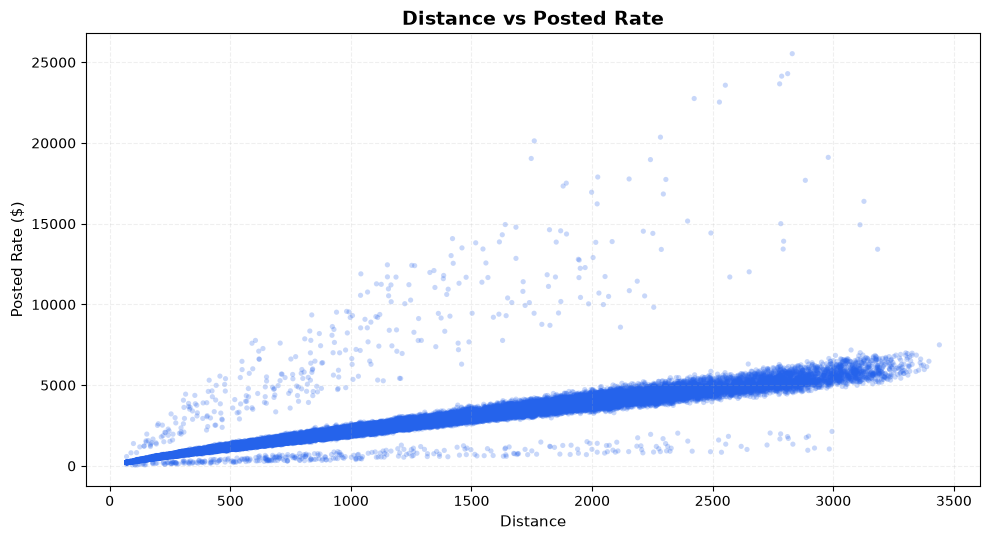

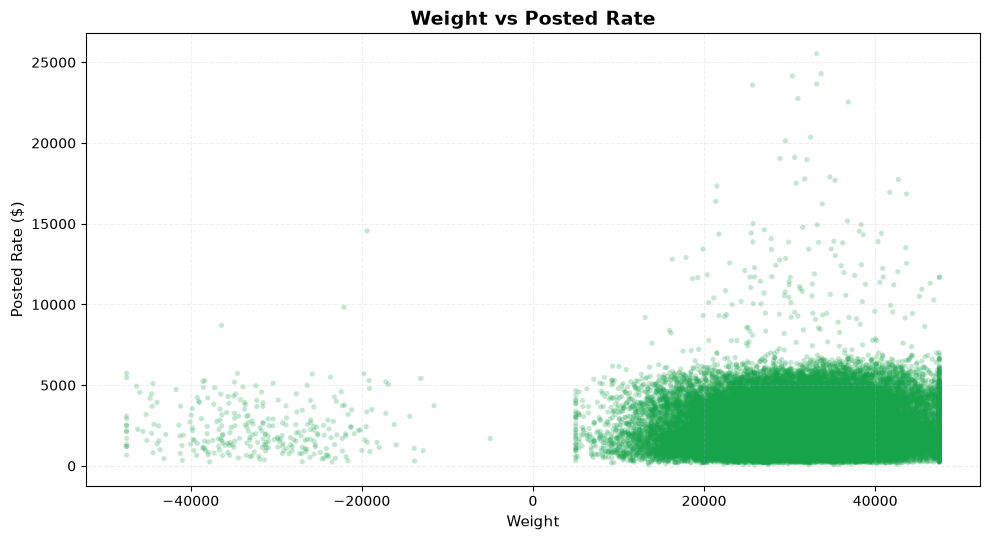

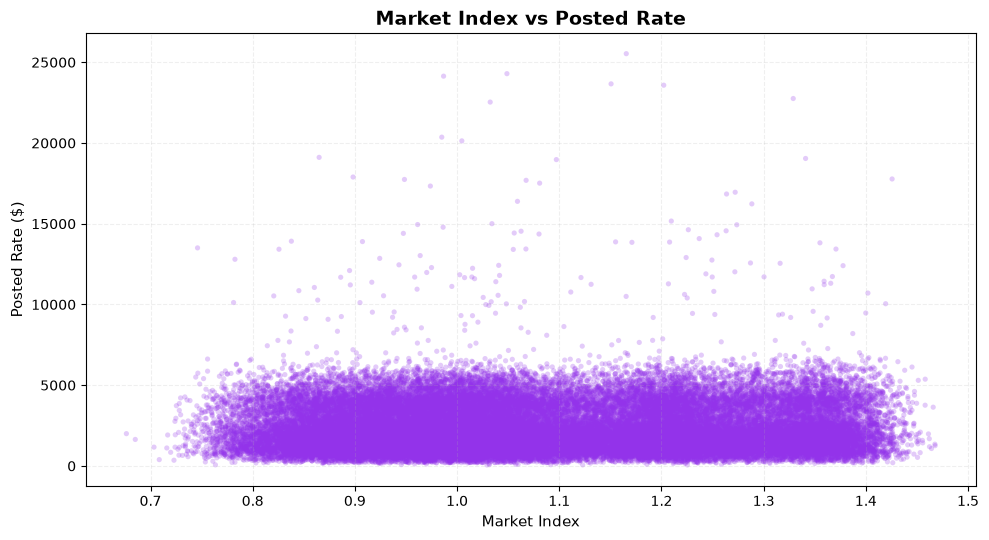

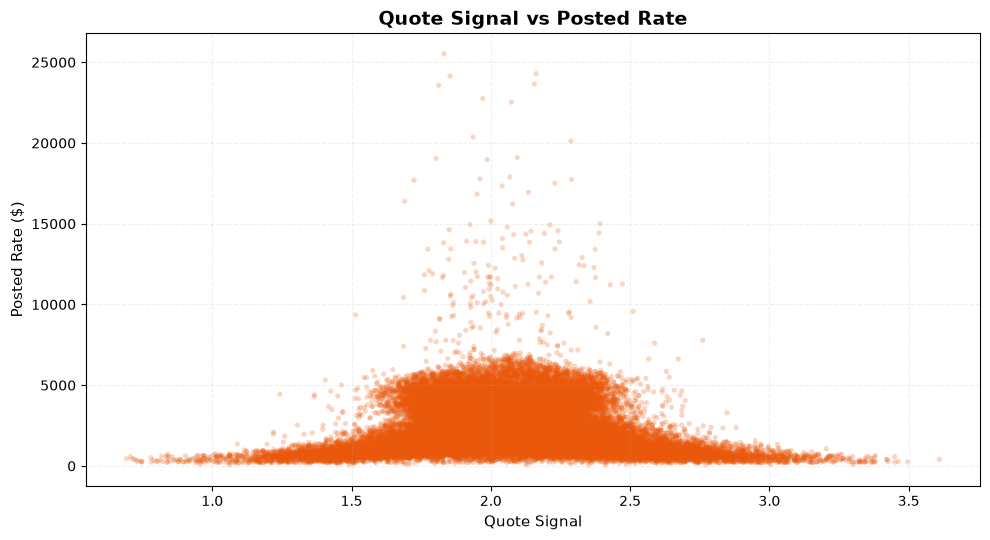

In [20]:
# SCATTER PLOTS

features_to_plot = [
    "distance",
    "weight",
    "market_index",
    "quote_signal"
]

colors = {
    "distance": "#2563EB",      # Blue
    "weight": "#16A34A",        # Green
    "market_index": "#9333EA",  # Purple
    "quote_signal": "#EA580C"   # Orange
}

for feature in features_to_plot:

    plot_data = train[[feature, "posted_rate"]].dropna()

    plt.figure(figsize=(10, 5.5))

    plt.scatter(
        plot_data[feature],
        plot_data["posted_rate"],
        s=14,
        alpha=0.25,
        color=colors[feature],
        edgecolors="none"
    )

    plt.xlabel(feature.replace("_", " ").title(), fontsize=11)
    plt.ylabel("Posted Rate ($)", fontsize=11)

    plt.title(
        f"{feature.replace('_', ' ').title()} vs Posted Rate",
        fontsize=14,
        fontweight="bold"
    )

    plt.grid(
        True,
        alpha=0.2,
        linestyle="--"
    )

    plt.tight_layout()
    plt.show()

In [21]:
# EQUIPMENT ANALYSIS

equipment_stats = (
    train.groupby("equipment")["posted_rate"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

display(equipment_stats)

,count,mean,median,std
equipment,,,,
Reefer,12045,2553.636939,2196.670,1589.670824
Flatbed,8753,2445.087223,2076.810,1505.053087
Dry Van,27202,2271.548686,1953.035,1423.029914


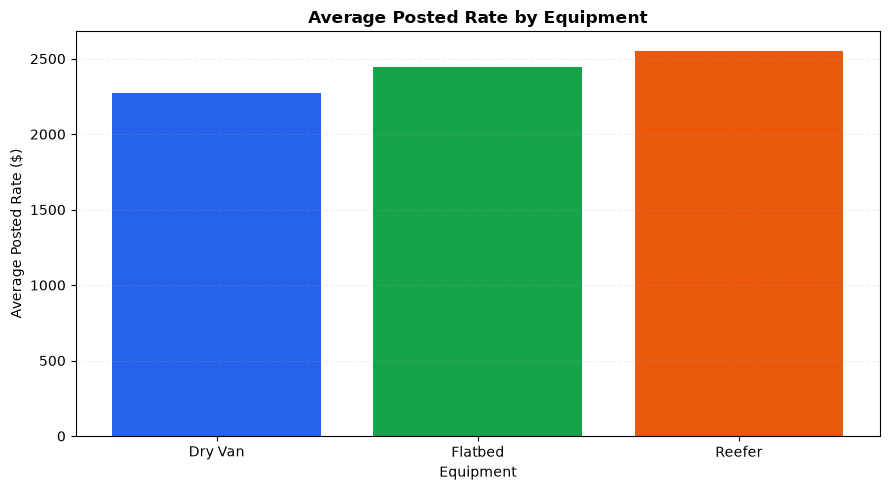

In [22]:
plt.figure(figsize=(9, 5))

equipment_order = (
    train.groupby("equipment")["posted_rate"]
    .mean()
    .sort_values()
)

plt.bar(
    equipment_order.index,
    equipment_order.values,
    color=["#2563EB", "#16A34A", "#EA580C"]
)

plt.xlabel("Equipment")
plt.ylabel("Average Posted Rate ($)")
plt.title("Average Posted Rate by Equipment", fontweight="bold")

plt.grid(axis="y", alpha=0.2, linestyle="--")
plt.tight_layout()
plt.show()

In [23]:
# PICKUP LOCATION ANALYSIS

pickup_stats = (
    train.groupby("pickup")["posted_rate"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

display(pickup_stats.head(15))

,count,mean,median
pickup,,,
San Francisco,453,4071.207108,4301.810
Fresno,827,3878.910000,4160.280
Reno,642,3765.391199,3836.925
Phoenix,1121,3764.774764,3935.620
Los Angeles,945,3729.638392,3996.610
Bakersfield,1193,3519.365448,3804.880
Tucson,944,3310.996271,3535.995
Las Vegas,277,3292.821913,3633.060
Salt Lake City,394,3144.764112,3316.265


In [24]:
# DELIVERY LOCATION ANALYSIS

delivery_stats = (
    train.groupby("delivery")["posted_rate"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

display(delivery_stats.head(15))

,count,mean,median
delivery,,,
San Francisco,467,4064.472998,4356.600
Fresno,763,3865.377156,4140.170
Phoenix,1090,3751.473110,3921.980
Los Angeles,955,3742.250932,4046.090
Reno,653,3679.871639,3783.880
Bakersfield,1156,3532.198893,3742.535
Las Vegas,292,3428.375274,3707.765
Tucson,997,3363.189789,3591.790
Salt Lake City,406,3164.350788,3316.060


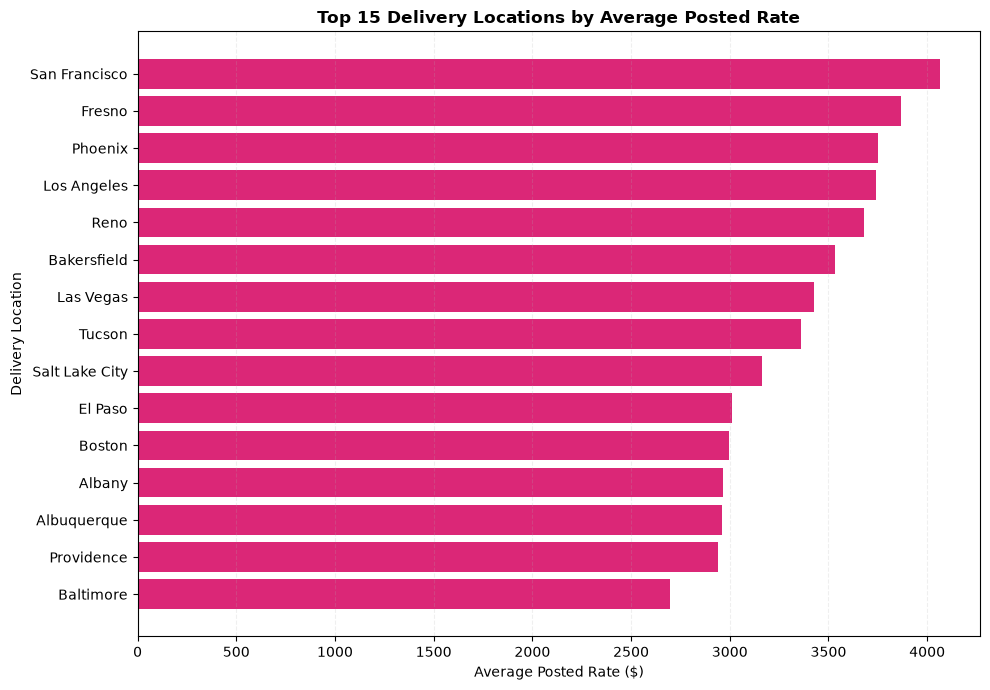

In [25]:
top_deliveries = delivery_stats.head(15).sort_values("mean")

plt.figure(figsize=(10, 7))

plt.barh(
    top_deliveries.index,
    top_deliveries["mean"],
    color="#DB2777"
)

plt.xlabel("Average Posted Rate ($)")
plt.ylabel("Delivery Location")
plt.title("Top 15 Delivery Locations by Average Posted Rate", fontweight="bold")

plt.grid(axis="x", alpha=0.2, linestyle="--")
plt.tight_layout()
plt.show()

In [26]:
# ROUTE ANALYSIS

train["route"] = train["pickup"] + " → " + train["delivery"]

route_stats = (
    train.groupby("route")["posted_rate"]
    .agg(["count", "mean", "median"])
    .sort_values("count", ascending=False)
)

display(route_stats.head(15))

,count,mean,median
route,,,
Columbia → Oklahoma City,39,2330.734615,2327.430
Phoenix → Shreveport,39,3507.618462,3554.430
Lexington → Atlanta,39,560.106154,553.630
Fort Wayne → Philadelphia,38,1681.032632,1708.835
Shreveport → Hartford,37,2867.768108,2812.520
Fort Wayne → Hartford,37,1938.657297,1725.990
Richmond → Oklahoma City,37,3093.435946,3126.490
Richmond → Phoenix,37,5190.194595,5010.880
Lexington → Kansas City,37,1042.474595,1029.800


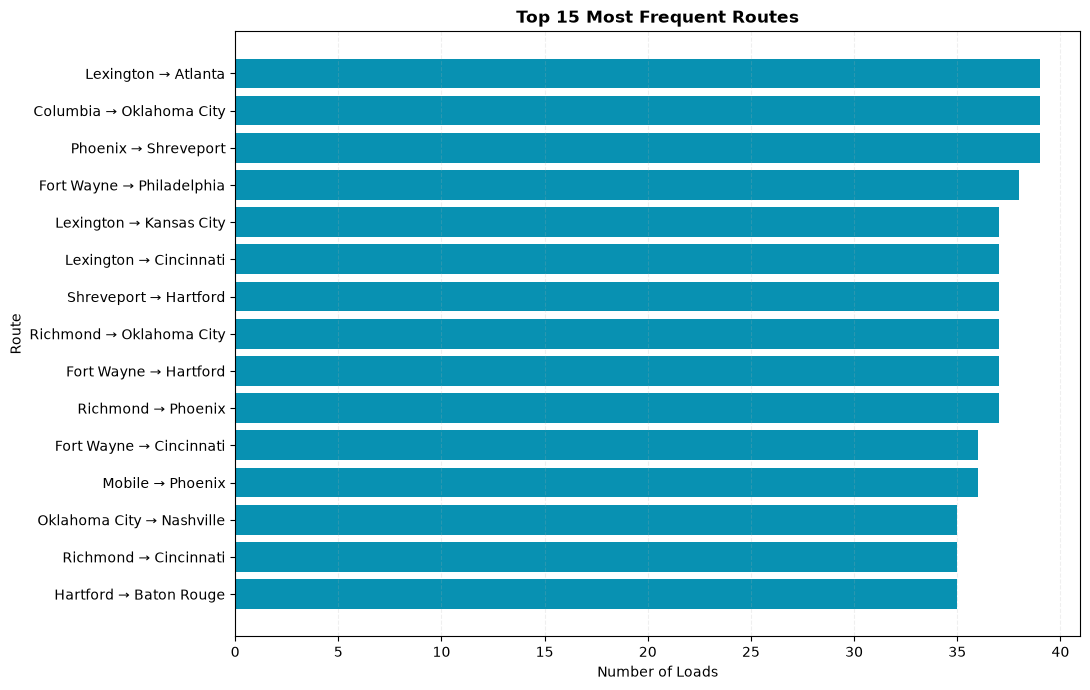

In [27]:
top_routes = route_stats.head(15).sort_values("count")

plt.figure(figsize=(11, 7))

plt.barh(
    top_routes.index,
    top_routes["count"],
    color="#0891B2"
)

plt.xlabel("Number of Loads")
plt.ylabel("Route")
plt.title("Top 15 Most Frequent Routes", fontweight="bold")

plt.grid(axis="x", alpha=0.2, linestyle="--")
plt.tight_layout()
plt.show()

In [28]:
# =========================
# TRAIN vs VALIDATION
# NUMERIC DISTRIBUTION SHIFT
# =========================

numeric_features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal"
]

comparison = pd.DataFrame({
    "train_mean": train[numeric_features].mean(),
    "validation_mean": validation[numeric_features].mean(),
    "train_median": train[numeric_features].median(),
    "validation_median": validation[numeric_features].median()
})

display(comparison)

,train_mean,validation_mean,train_median,validation_median
distance,1135.856654,1141.773100,953.30000,953.60000
weight,31028.844004,30506.636248,31436.50000,31193.00000
market_index,1.083387,0.926913,1.05580,0.92290
quote_signal,2.062468,2.051334,2.05575,2.05123


In [29]:
shift = pd.DataFrame({
    "train_mean": train[numeric_features].mean(),
    "validation_mean": validation[numeric_features].mean()
})

shift["mean_change_pct"] = (
    (shift["validation_mean"] - shift["train_mean"])
    / shift["train_mean"]
    * 100
).round(2)

display(shift.sort_values("mean_change_pct", ascending=False))

,train_mean,validation_mean,mean_change_pct
distance,1135.856654,1141.773100,0.52
quote_signal,2.062468,2.051334,-0.54
weight,31028.844004,30506.636248,-1.68
market_index,1.083387,0.926913,-14.44


In [30]:
# EQUIPMENT SHIFT

train_equipment = (
    train["equipment"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("train_pct")
)

validation_equipment = (
    validation["equipment"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("validation_pct")
)

equipment_shift = pd.concat(
    [train_equipment, validation_equipment],
    axis=1
).fillna(0)

display(equipment_shift)

,train_pct,validation_pct
equipment,,
Dry Van,56.670833,56.500
Reefer,25.093750,25.425
Flatbed,18.235417,18.075


In [31]:
# UNSEEN LOCATIONS

train_pickups = set(train["pickup"].unique())
train_deliveries = set(train["delivery"].unique())

validation_pickups = set(validation["pickup"].unique())
validation_deliveries = set(validation["delivery"].unique())

unseen_pickups = sorted(validation_pickups - train_pickups)
unseen_deliveries = sorted(validation_deliveries - train_deliveries)

print("Unseen pickup locations:")
print(unseen_pickups)

print("\nUnseen delivery locations:")
print(unseen_deliveries)

print("\nNumber of unseen pickups:", len(unseen_pickups))
print("Number of unseen deliveries:", len(unseen_deliveries))

Unseen pickup locations:
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']

Unseen delivery locations:
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']

Number of unseen pickups: 8
Number of unseen deliveries: 8


In [32]:
# UNSEEN ROUTES

train_routes = set(
    train["pickup"] + " → " + train["delivery"]
)

validation_routes = set(
    validation["pickup"] + " → " + validation["delivery"]
)

unseen_routes = sorted(validation_routes - train_routes)

print("Total train routes:", len(train_routes))
print("Total validation routes:", len(validation_routes))
print("Unseen validation routes:", len(unseen_routes))

print("\nSample unseen routes:")
for route in unseen_routes[:20]:
    print(route)

Total train routes: 4014
Total validation routes: 4214
Unseen validation routes: 736

Sample unseen routes:
Albany → Allentown
Albany → Charlotte
Albany → Chicago
Albany → Jackson
Albany → Knoxville
Albany → Laredo
Albany → Norfolk
Albany → San Diego
Albuquerque → Allentown
Albuquerque → Charlotte
Albuquerque → Jackson
Albuquerque → Knoxville
Albuquerque → San Diego
Allentown → Albany
Allentown → Albuquerque
Allentown → Amarillo
Allentown → Austin
Allentown → Bakersfield
Allentown → Baltimore
Allentown → Baton Rouge


In [33]:
# TIME-BASED VALIDATION SPLIT

development_train = train[
    train["date"] < "2025-09-01"
].copy()

development_valid = train[
    train["date"] >= "2025-09-01"
].copy()

print("Development train:")
print(development_train["date"].min(), "→", development_train["date"].max())
print("Rows:", len(development_train))

print("\nDevelopment validation:")
print(development_valid["date"].min(), "→", development_valid["date"].max())
print("Rows:", len(development_valid))

Development train:
2025-01-01 00:00:00 → 2025-08-31 00:00:00
Rows: 38477

Development validation:
2025-09-01 00:00:00 → 2025-10-31 00:00:00
Rows: 9523


In [35]:
def create_features(df):
    df = df.copy()

    # Time features
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek
    df["day_of_month"] = df["date"].dt.day
    df["day_of_year"] = df["date"].dt.dayofyear

    # Continuous time index
    df["days_since_start"] = (
        df["date"] - pd.Timestamp("2025-01-01")
    ).dt.days

    # Geographical features
    df["lat_diff"] = (
        df["delivery_lat"] - df["pickup_lat"]
    ).abs()

    df["lon_diff"] = (
        df["delivery_lon"] - df["pickup_lon"]
    ).abs()

    # Weight / distance relationship
    df["weight_per_distance"] = (
        df["weight"] / df["distance"].replace(0, np.nan)
    )

    return df

In [36]:
development_train_fe = create_features(development_train)
development_valid_fe = create_features(development_valid)

print("Train shape:", development_train_fe.shape)
print("Validation shape:", development_valid_fe.shape)

display(development_train_fe.head())

Train shape: (38477, 24)
Validation shape: (9523, 24)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate,route,year,month,day_of_week,day_of_month,day_of_year,days_since_start,lat_diff,lon_diff,weight_per_distance
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41,Richmond → Baltimore,2025,1,2,1,1,0,0.07786,4.04342,111.768137
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97,Richmond → Philadelphia,2025,1,2,1,1,0,1.13195,3.82196,62.584670
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54,Philadelphia → Green Bay,2025,1,2,1,1,0,5.07979,14.56161,32.776400
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28,Hartford → Atlanta,2025,1,2,1,1,0,4.70395,14.10889,33.491817
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28,Dallas → Nashville,2025,1,2,1,1,0,3.46454,6.29428,64.925263


In [34]:
print("Train period:")
display(
    development_train.groupby(
        development_train["date"].dt.to_period("M")
    ).size()
)

print("\nValidation period:")
display(
    development_valid.groupby(
        development_valid["date"].dt.to_period("M")
    ).size()
)

Train period:


date
2025-01    4918
2025-02    4337
2025-03    5036
2025-04    4819
2025-05    4913
2025-06    4783
2025-07    4912
2025-08    4759
Freq: M, dtype: int64


Validation period:


date
2025-09    4670
2025-10    4853
Freq: M, dtype: int64

In [37]:
feature_cols = [
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "equipment",
    "weight",
    "market_index",
    "quote_signal",
    "year",
    "month",
    "day_of_week",
    "day_of_month",
    "day_of_year",
    "days_since_start",
    "lat_diff",
    "lon_diff",
    "weight_per_distance",
]

target_col = "posted_rate"

X_train = development_train_fe[feature_cols]
y_train = development_train_fe[target_col]

X_valid = development_valid_fe[feature_cols]
y_valid = development_valid_fe[target_col]

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (38477, 20)
X_valid: (9523, 20)
y_train: (38477,)
y_valid: (9523,)


In [42]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

categorical_features = [
    "pickup",
    "delivery",
    "equipment"
]

numeric_features = [
    col for col in feature_cols
    if col not in categorical_features
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 17
Categorical features: 3


In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

start_time = time.time()

baseline_model.fit(X_train, y_train)

train_time = time.time() - start_time

valid_predictions = baseline_model.predict(X_valid)

mae = mean_absolute_error(y_valid, valid_predictions)
rmse = np.sqrt(mean_squared_error(y_valid, valid_predictions))

print(f"Training time: {train_time:.2f} seconds")
print(f"Validation MAE: ${mae:,.2f}")
print(f"Validation RMSE: ${rmse:,.2f}")

Training time: 525.59 seconds
Validation MAE: $164.65
Validation RMSE: $660.20


In [52]:
model_results = []

model_results.append({
    "model": "Random Forest",
    "MAE": mae,
    "RMSE": rmse,
    "training_time_sec": train_time
})

display(pd.DataFrame(model_results))

,model,MAE,RMSE,training_time_sec
0,Random Forest,164.651095,660.202251,525.590328


In [47]:
gradient_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

gradient_preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", gradient_categorical_pipeline, categorical_features)
])

In [48]:
gradient_model = Pipeline([
    ("preprocessor", gradient_preprocessor),
    ("model", HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.08,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42
    ))
])

start_time = time.time()

gradient_model.fit(X_train, y_train)

gradient_train_time = time.time() - start_time

gradient_predictions = gradient_model.predict(X_valid)

gradient_mae = mean_absolute_error(
    y_valid,
    gradient_predictions
)

gradient_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        gradient_predictions
    )
)

print(f"Training time: {gradient_train_time:.2f} seconds")
print(f"Validation MAE: ${gradient_mae:,.2f}")
print(f"Validation RMSE: ${gradient_rmse:,.2f}")

Training time: 7.56 seconds
Validation MAE: $129.79
Validation RMSE: $634.44


In [50]:
model_results.append({
    "model": "HistGradientBoosting",
    "MAE": gradient_mae,
    "RMSE": gradient_rmse,
    "training_time_sec": gradient_train_time
})

display(
    pd.DataFrame(model_results).sort_values("MAE")
)

,model,MAE,RMSE,training_time_sec
1,HistGradientBoosting,129.786062,634.442181,7.562436
0,Random Forest,164.651095,660.202251,525.590328


In [53]:
gradient_mae_model = Pipeline([
    ("preprocessor", gradient_preprocessor),
    ("model", HistGradientBoostingRegressor(
        loss="absolute_error",
        max_iter=300,
        learning_rate=0.08,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42
    ))
])

start_time = time.time()

gradient_mae_model.fit(X_train, y_train)

gradient_mae_train_time = time.time() - start_time

gradient_mae_predictions = gradient_mae_model.predict(X_valid)

gradient_mae_score = mean_absolute_error(
    y_valid,
    gradient_mae_predictions
)

gradient_mae_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        gradient_mae_predictions
    )
)

print(f"Training time: {gradient_mae_train_time:.2f} seconds")
print(f"Validation MAE: ${gradient_mae_score:,.2f}")
print(f"Validation RMSE: ${gradient_mae_rmse:,.2f}")

Training time: 11.11 seconds
Validation MAE: $111.73
Validation RMSE: $636.11


In [54]:
error_analysis = development_valid_fe[
    [
        "load_id",
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "posted_rate"
    ]
].copy()

error_analysis["predicted_rate"] = gradient_mae_predictions

error_analysis["absolute_error"] = (
    error_analysis["posted_rate"]
    - error_analysis["predicted_rate"]
).abs()

error_analysis["percentage_error"] = (
    error_analysis["absolute_error"]
    / error_analysis["posted_rate"]
) * 100

display(
    error_analysis[
        [
            "posted_rate",
            "predicted_rate",
            "absolute_error",
            "percentage_error"
        ]
    ].describe()
)

,posted_rate,predicted_rate,absolute_error,percentage_error
count,9523.000000,9523.000000,9523.000000,9523.000000
mean,2392.450169,2313.395522,111.730745,4.793220
std,1526.132503,1341.208881,626.255110,24.947473
min,104.380000,204.029048,0.001846,0.000185
25%,1243.060000,1233.848069,15.220094,0.952647
50%,2044.320000,2005.206971,36.107316,1.996439
75%,3335.735000,3250.481113,75.735139,3.352336
max,20361.890000,6473.151597,16293.451805,472.040088


In [55]:
display(
    error_analysis
    .sort_values("absolute_error", ascending=False)
    .head(20)
)

,load_id,pickup,delivery,distance,equipment,weight,date,posted_rate,predicted_rate,absolute_error,percentage_error
40096,TR-040097,Baltimore,Oklahoma City,1760.3,Reefer,29521.0,2025-09-11,20132.37,3838.918195,16293.451805,80.931613
40171,TR-040172,Montgomery,Fresno,2283.4,Dry Van,32447.0,2025-09-11,20361.89,4303.473620,16058.416380,78.865058
43539,TR-043540,Milwaukee,Bakersfield,1893.0,Dry Van,30760.0,2025-10-03,17514.11,3599.063601,13915.046399,79.450491
46213,TR-046214,Columbia,Tucson,2023.4,Flatbed,34710.0,2025-10-20,17893.17,4058.624225,13834.545775,77.317467
47298,TR-047299,Boston,Bakersfield,2979.1,Reefer,30585.0,2025-10-27,19110.30,5889.577712,13220.722288,69.181134
40322,TR-040323,Montgomery,El Paso,1639.9,Dry Van,38363.0,2025-09-12,14949.25,3227.749955,11721.500045,78.408616
46516,TR-046517,Toledo,Albuquerque,1684.3,Reefer,31536.0,2025-10-22,14784.38,3596.021899,11188.358101,75.676884
42881,TR-042882,San Antonio,Detroit,1460.5,Dry Van,43567.0,2025-09-29,13503.63,2872.487049,10631.142951,78.728038
42149,TR-042150,Grand Rapids,Lubbock,1415.5,Dry Van,35333.0,2025-09-24,13026.22,2754.838960,10271.381040,78.851586
47536,TR-047537,Los Angeles,Richmond,2782.4,Dry Van,25730.0,2025-10-29,15003.55,4877.491076,10126.058924,67.491087


In [56]:
high_rate_threshold = development_valid_fe["posted_rate"].quantile(0.95)

error_analysis["rate_group"] = np.where(
    error_analysis["posted_rate"] >= high_rate_threshold,
    "Top 5% rate",
    "Other"
)

group_summary = (
    error_analysis
    .groupby("rate_group")
    .agg(
        rows=("posted_rate", "size"),
        actual_mean=("posted_rate", "mean"),
        predicted_mean=("predicted_rate", "mean"),
        mae=("absolute_error", "mean"),
        median_absolute_error=("absolute_error", "median"),
        rmse=("absolute_error", lambda x: np.sqrt(np.mean(x**2)))
    )
    .round(2)
)

display(group_summary)

,rows,actual_mean,predicted_mean,mae,median_absolute_error,rmse
rate_group,,,,,,
Other,9046,2197.03,2162.28,68.56,33.83,218.58
Top 5% rate,477,6098.45,5179.18,930.40,159.62,2678.12


In [57]:
high_rate_cases = error_analysis[
    error_analysis["posted_rate"] >= high_rate_threshold
].copy()

display(
    high_rate_cases[
        [
            "pickup",
            "delivery",
            "distance",
            "equipment",
            "weight",
            "date",
            "posted_rate",
            "predicted_rate",
            "absolute_error",
            "percentage_error"
        ]
    ]
    .sort_values("posted_rate", ascending=False)
    .head(20)
)

,pickup,delivery,distance,equipment,weight,date,posted_rate,predicted_rate,absolute_error,percentage_error
40171,Montgomery,Fresno,2283.4,Dry Van,32447.0,2025-09-11,20361.89,4303.473620,16058.416380,78.865058
40096,Baltimore,Oklahoma City,1760.3,Reefer,29521.0,2025-09-11,20132.37,3838.918195,16293.451805,80.931613
47298,Boston,Bakersfield,2979.1,Reefer,30585.0,2025-10-27,19110.30,5889.577712,13220.722288,69.181134
46213,Columbia,Tucson,2023.4,Flatbed,34710.0,2025-10-20,17893.17,4058.624225,13834.545775,77.317467
43539,Milwaukee,Bakersfield,1893.0,Dry Van,30760.0,2025-10-03,17514.11,3599.063601,13915.046399,79.450491
47536,Los Angeles,Richmond,2782.4,Dry Van,25730.0,2025-10-29,15003.55,4877.491076,10126.058924,67.491087
40322,Montgomery,El Paso,1639.9,Dry Van,38363.0,2025-09-12,14949.25,3227.749955,11721.500045,78.408616
46516,Toledo,Albuquerque,1684.3,Reefer,31536.0,2025-10-22,14784.38,3596.021899,11188.358101,75.676884
44267,Albany,Albuquerque,2492.6,Dry Van,25513.0,2025-10-08,14425.42,4346.886533,10078.533467,69.866482
46366,Bakersfield,Columbia,2251.9,Dry Van,40729.0,2025-10-21,14403.14,4313.553972,10089.586028,70.051295


In [58]:
high_rate_cases_full = development_valid_fe[
    development_valid_fe["posted_rate"] >= high_rate_threshold
].copy()

high_rate_cases_full["predicted_rate"] = gradient_mae_predictions[
    development_valid_fe["posted_rate"] >= high_rate_threshold
]

display(
    high_rate_cases_full[
        [
            "pickup",
            "delivery",
            "distance",
            "equipment",
            "weight",
            "market_index",
            "quote_signal",
            "date",
            "posted_rate",
            "predicted_rate"
        ]
    ]
    .sort_values("posted_rate", ascending=False)
    .head(30)
)

,pickup,delivery,distance,equipment,weight,market_index,quote_signal,date,posted_rate,predicted_rate
40171,Montgomery,Fresno,2283.4,Dry Van,32447.0,0.98502,1.93645,2025-09-11,20361.89,4303.473620
40096,Baltimore,Oklahoma City,1760.3,Reefer,29521.0,1.00464,2.28753,2025-09-11,20132.37,3838.918195
47298,Boston,Bakersfield,2979.1,Reefer,30585.0,0.86501,2.09472,2025-10-27,19110.30,5889.577712
46213,Columbia,Tucson,2023.4,Flatbed,34710.0,0.89822,2.06797,2025-10-20,17893.17,4058.624225
43539,Milwaukee,Bakersfield,1893.0,Dry Van,30760.0,1.08079,2.22972,2025-10-03,17514.11,3599.063601
47536,Los Angeles,Richmond,2782.4,Dry Van,25730.0,1.03410,2.39203,2025-10-29,15003.55,4877.491076
40322,Montgomery,El Paso,1639.9,Dry Van,38363.0,0.96139,1.92501,2025-09-12,14949.25,3227.749955
46516,Toledo,Albuquerque,1684.3,Reefer,31536.0,0.98632,2.05917,2025-10-22,14784.38,3596.021899
44267,Albany,Albuquerque,2492.6,Dry Van,25513.0,1.05590,2.38846,2025-10-08,14425.42,4346.886533
46366,Bakersfield,Columbia,2251.9,Dry Van,40729.0,0.94743,2.19163,2025-10-21,14403.14,4313.553972
